In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae
from sklearn.preprocessing import PolynomialFeatures
import joblib

In [118]:
models = []

for i in range(63):
    reg = pd.read_excel(f"Данные по регионам\\region {i}.xlsx", index_col=False)
    features, target = reg.iloc[:, 2:], reg.iloc[:, 1]
    poly = PolynomialFeatures(3)
    features = poly.fit_transform(features)

    X_train, y_train = features[:730], target[:730]

    model = LinearRegression()
    model.fit(X_train, y_train)

    features, target = features[730:], target[730:]
    rmses = []

    while features.shape[0] > 0:
        predicts = []

        if features.shape[0] > 30:
            for i in range(30):
                predicts.append(model.predict(features[i].reshape(1, -1)))

            rmses.append(np.sqrt(mse(target[:30], predicts)))
            X_train, y_train = np.append(X_train, features[:30], axis = 0), np.append(y_train, target[:30])
            model.fit(X_train, y_train)
            features = features[30:]
            target = target[30:]
                

        elif features.shape[0] <= 30:
            c = features.shape[0]
            for i in range(c):
                predicts.append(model.predict(features[i].reshape(1, -1)))

            rmses.append(np.sqrt(mse(target[:c], predicts)))
            X_train, y_train = np.append(X_train, features[:c], axis = 0), np.append(y_train, target[:c])
            model.fit(X_train, y_train)
            features = features[c:]
            target = target[c:]

    models.append(model)

In [121]:
for i in range(63):
    joblib.dump(models[i], f"linear_regression_{i}.pkl")

In [99]:
conf_ints = []

for k in range(63):

    reg = pd.read_excel(f"Данные по регионам\\region {k}.xlsx", index_col=False)

    if k in (2, 17, 19, 24):
        reg = reg.iloc[2000:]

        
    features, target = reg.iloc[:, 2:], reg.iloc[:, 1]

    poly = PolynomialFeatures(3)
    features = poly.fit_transform(features)

    X, y = features, target
    X_train, y_train = X[1825:], y[1825:]

    model = LinearRegression()
    model.fit(X_train, y_train)

    features, target = features[1825:], target[1825:]

    for i in range(0, len(target)-7, 7):

        for j in range(i, i+7):

            prediction = model.predict(features[j:j+7])

    model.fit(X[i:1825+i], y[i:1825+i])

    conf_ints.append(confidence_interval(y))

    joblib.dump(model, f"linear{k}.joblib")
    





In [100]:
with open('conf_ints.txt', 'w') as f:
    # Проходим по каждому подсписку
    for sublist in conf_ints:
        # Преобразуем элементы подсписка в строки и объединяем их через пробел
        line = ' '.join(str(item) for item in sublist)
        # Записываем строку в файл
        f.write(line + '\n')

In [82]:
reg = pd.read_excel("Данные по регионам\\region 0.xlsx", index_col=False)

In [85]:
features, target = reg.iloc[:, 2:], reg.iloc[:, 1]

In [74]:
from sklearn.preprocessing import PolynomialFeatures

features, target = reg.iloc[:, 2:], reg.iloc[:, 1]

poly = PolynomialFeatures(3)
features = poly.fit_transform(features)

X, y = features, target

In [75]:
X_train, y_train = X[1825:], y[1825:]

In [60]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [86]:
features, target = features[1825:], target[1825:]

In [62]:
rmses = []
maes = []
predictions = []
lower_bounds = []
upper_bounds = []


for i in range(0, len(target)-7, 7):

    predicts = []
    confs = []

    for j in range(i, i+7):

        prediction = model.predict(features[j:j+7])
        rmses.append(np.sqrt(mse(prediction, target[j:j+7])))
        maes.append(mae(prediction, target[j:j+7]))
        predicts.append(prediction)

    predictions.append(predicts[0])

    model.fit(X[i:1825+i], y[i:1825+i])

In [63]:
predictions = np.array(predictions).flatten()

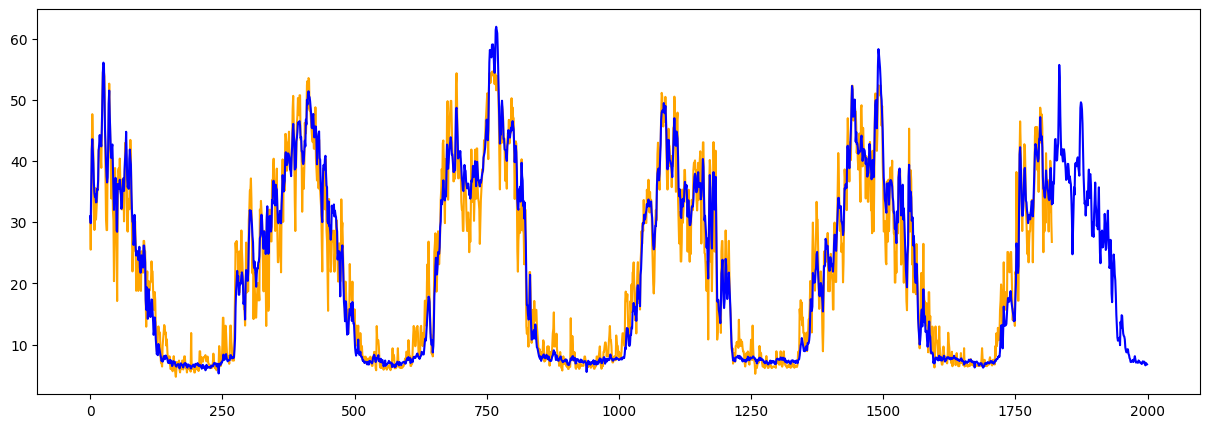

In [64]:
plt.figure(figsize=(15, 5))
plt.plot(predictions[:2000], color="orange", label='predicted values')
plt.plot(np.array(y)[:2000], color="blue", label='true values')
plt.show()

In [54]:
predictions

array([146.69722   , 131.57929422, 126.52302768, ..., 159.15135428,
       149.16408946, 149.16408946])

In [89]:
import statsmodels.api as sm
alpha = 0.05 # 95% confidence interval
lr = sm.OLS(target, sm.add_constant(features)).fit()
conf_interval = lr.conf_int(alpha)

In [94]:
list(np.array(conf_interval)[0])

[38.790717818321774, 39.42511086253628]

In [98]:
def confidence_interval(predictions):

    mean = np.mean(predictions)
    std = np.std(predictions)

    lower_bound = mean - 1.96 * (std / np.sqrt(len(predictions)))
    upper_bound = mean + 1.96 * (std / np.sqrt(len(predictions)))

    return lower_bound, upper_bound

# Пример использования функции
bound = confidence_interval(y)
print(f"Доверительный интервал с вероятностью 95%: {bound}")

Доверительный интервал с вероятностью 95%: (151.54509767081294, 160.49834180841265)


In [104]:
features, target = features[730:], target[730:]
rmses = []

while features.shape[0] > 0:
    predicts = []

    if features.shape[0] > 30:
        for i in range(30):
           predicts.append(model.predict(features[i].reshape(1, -1)))

        rmses.append(np.sqrt(mse(target[:30], predicts)))
        X_train, y_train = np.append(X_train, features[:30], axis = 0), np.append(y_train, target[:30])
        model.fit(X_train, y_train)
        features = features[30:]
        target = target[30:]
        

    elif features.shape[0] <= 30:
        c = features.shape[0]
        for i in range(c):
            predicts.append(model.predict(features[i].reshape(1, -1)))

        rmses.append(np.sqrt(mse(target[:c], predicts)))
        X_train, y_train = np.append(X_train, features[:c], axis = 0), np.append(y_train, target[:c])
        model.fit(X_train, y_train)
        features = features[c:]
        target = target[c:]

        




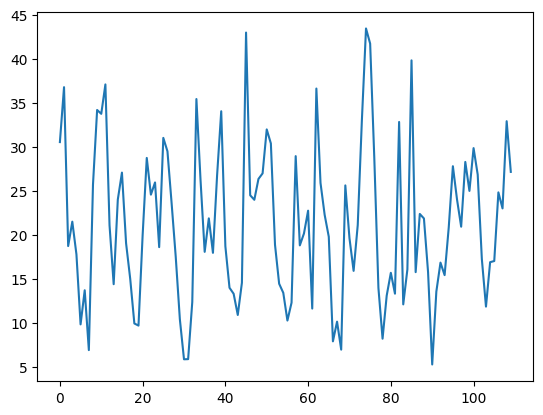

In [105]:
plt.plot(rmses)
plt.show()

4030

In [63]:
features, target = features[730:], target[730:]
X_train = np.append(X_train, features[:30], axis=0)

In [71]:
np.append(y_train, target[:30])

array([30.97228214, 29.8463619 , 36.35965166, 41.85907104, 43.56730441,
       41.69058499, 39.60401614, 36.41539943, 34.76497306, 34.15694213,
       34.52954269, 33.24082594, 33.29307868, 35.41033372, 35.21566697,
       36.76662836, 41.69292863, 42.74232168, 44.23712021, 42.67672866,
       43.18458919, 42.39077177, 45.29770847, 49.73437924, 54.55156719,
       56.06897342, 55.60322054, 50.94297971, 45.07700319, 42.55998904,
       39.46867748, 37.46985909, 36.49654254, 37.32410793, 41.8644199 ,
       49.3721653 , 51.5085657 , 47.50052636, 44.84466038, 41.7436958 ,
       40.48230659, 42.20757211, 42.69831535, 38.72652099, 35.28372658,
       32.01461522, 35.24782345, 36.39025882, 37.24161869, 34.75027602,
       28.61645501, 28.43790247, 36.24174498, 35.45037724, 35.96785857,
       35.44913085, 36.9375853 , 35.11797363, 34.48716696, 32.20058111,
       32.60403768, 35.53035667, 36.67462142, 37.12893463, 35.11107426,
       38.5272935 , 40.29613683, 41.64554068, 44.77805901, 41.06

In [45]:
f = poly.fit_transform([[-6, 3]])
print(model.predict(f))

[50.50185927]


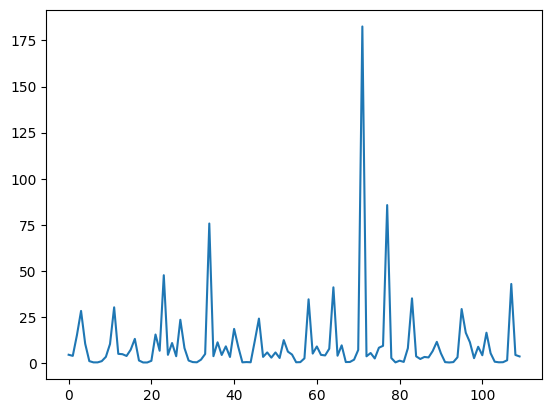

In [35]:
plt.plot(rmses)
plt.show()

In [146]:
import joblib 
  
  
# Save the model as a pickle in a file 
joblib.dump(model, 'linear_regression_0.pkl') 

['linear_regression_0.pkl']

In [3]:
a = [1, 2]
b = [3, 4]
c = [5, 6]

for i in zip(a, b, c):
    print(list(i))

[1, 3, 5]
[2, 4, 6]


In [7]:
pd.read_excel("Данныe по регионам\\region 0.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'Данныe по регионам\\region 0.xlsx'